## Avance 2 – Modelos Avanzados y Optimización ##

En este avance se desarrollan y comparan modelos supervisados avanzados para la predicción de churn en FinanceGuard, con el objetivo de mejorar el desempeño del modelo baseline del Avance 1.

Se evalúan distintos algoritmos (Random Forest y modelos de Gradient Boosting), se aplica optimización de hiperparámetros exclusivamente a XGBoost, y se implementa un modelo de ensemble mediante Stacking.
La evaluación se realiza utilizando validación cruzada estratificada y métricas adecuadas para datos desbalanceados, priorizando Recall y PR-AUC.

Este análisis permite identificar el modelo más adecuado para apoyar estrategias de retención de clientes, integrando criterios técnicos y de negocio.

In [1]:

# 1) Importaciones y config

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [8]:
# 2) Carga de datos

df = pd.read_csv("Churn_Modelling (1).csv")

print("Dimensión del dataset:", df.shape)
df.head()


Dimensión del dataset: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
# 3) Limpieza mínima de datos

df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:

# 4) Definición de X e y

X = df.drop(columns="Exited")
y = df["Exited"]

print("Distribución de la variable objetivo (Exited):")
print(y.value_counts())
print("\nProporción:")
print(y.value_counts(normalize=True))


Distribución de la variable objetivo (Exited):
Exited
0    7963
1    2037
Name: count, dtype: int64

Proporción:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


En este bloque se analiza la variable objetivo del problema (Exited), que indica si un cliente abandonó el banco (1) o no (0).
Los resultados muestran que:
7.963 clientes (≈79,6%) no abandonaron el banco.
2.037 clientes (≈20,4%) sí abandonaron.
Esto confirma que el data set esta desbalanceado, por este motivo, en los siguientes pasos se utilizan métricas como Recall y PR-AUC, más adecuadas para este tipo de problemas.

In [11]:

# 5) Train / Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (8000, 10)
Test: (2000, 10)


En este bloque se divide el dataset en conjuntos de entrenamiento y prueba.
El parámetro stratify=y asegura que la proporción de clientes que abandonan y no abandonan se mantenga igual en ambos conjuntos, evitando sesgos en la evaluación del modelo.

In [12]:

# 6.1 Columnas categóricas y numéricas

categorical_features = ["Geography", "Gender"]

numeric_features = [
    col for col in X.columns if col not in categorical_features
]

print("Categóricas:", categorical_features)
print("Numéricas:", numeric_features)


Categóricas: ['Geography', 'Gender']
Numéricas: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [13]:

# 6.2 Preprocesamiento (ColumnTransformer)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop"
)


En este bloque se preparan los datos para que los modelos puedan aprender correctamente.
Las variables numéricas se estandarizan con StandardScaler, para que todas tengan una escala similar.
Las variables categóricas (Geography y Gender) se convierten en variables numéricas usando OneHotEncoder. Además, drop="first" evita información redundante al dejar una categoría como referencia.
handle_unknown="ignore" evita errores si aparece una categoría nueva en el conjunto de test.
remainder="drop" elimina cualquier columna que no esté incluida explícitamente.

Este preprocesamiento se aplica de forma automática dentro de los pipelines, asegurando consistencia entre entrenamiento y evaluación.


In [14]:

# 6.2 Check rápido del preprocesamiento

preprocessor.fit(X_train)

X_train_transformed = preprocessor.transform(X_train)

print("Shape X_train original:", X_train.shape)
print("Shape X_train transformado:", X_train_transformed.shape)


Shape X_train original: (8000, 10)
Shape X_train transformado: (8000, 11)


In [15]:

# 6.3 Validación cruzada

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


In [16]:

# 7.1 Modelo Random Forest

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)


class_weight="balanced" → churn desbalanceado

n_estimators=300 → estabilidad sin tuning

n_jobs=-1 → usa todos los núcleos

In [17]:

# 7.2 Pipeline Random Forest

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)


Aquí se integra el preprocesamiento y el modelo en un único pipeline.

In [19]:

# 7.3 Evaluación con Cross-Validation

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

rf_cv_results = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring.keys():
    print(f"{metric}: {rf_cv_results['test_' + metric].mean():.4f}")


accuracy: 0.8592
precision: 0.7685
recall: 0.4417
roc_auc: 0.8518
pr_auc: 0.6654



El modelo clasifica bien en general (accuracy alto).
Tiene buena precisión: cuando predice churn, suele acertar.
El recall es medio (≈44%): típico en churn → se escapan clientes.
ROC-AUC > 0.85: excelente capacidad discriminativa.
PR-AUC ≈ 0.66: muy buen valor para un problema 80/20.

Conclusión:
Random Forest es un muy buen baseline avanzado, pero hay margen para mejorar recall y PR-AUC con boosting.

In [20]:

# 8.1 Modelo XGBoost (base)

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])
)


scale_pos_weight → clave para desbalance (churn)

subsample / colsample_bytree → reducen overfitting

In [21]:

# 8.2 Pipeline XGBoost

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)


In [22]:
# 8.3 Evaluación XGBoost con CV
# ==================================

xgb_cv_results = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring.keys():
    print(f"{metric}: {xgb_cv_results['test_' + metric].mean():.4f}")


accuracy: 0.8238
precision: 0.5579
recall: 0.6509
roc_auc: 0.8482
pr_auc: 0.6736


Aqui se evalúa el desempeño del modelo XGBoost base utilizando validación cruzada estratificada.

Los resultados muestran que:
El Recall aumenta significativamente respecto a Random Forest, indicando una mejor capacidad para detectar clientes que abandonan.
El PR-AUC mejora, lo que confirma un mejor desempeño sobre la clase minoritaria en un contexto desbalanceado.
La Accuracy disminuye levemente, lo cual es esperable cuando se prioriza capturar churn en lugar de maximizar aciertos globales.
El ROC-AUC se mantiene alto, mostrando una buena capacidad discriminatoria general.

En conjunto, XGBoost ofrece un mejor equilibrio entre detección de churn y estabilidad del modelo.

In [23]:

# 9.1 Modelo LightGBM (base)

lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    num_leaves=31,
    min_data_in_leaf=20,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)



Por qué estos parámetros

num_leaves, min_data_in_leaf → los más importantes en LightGBM
class_weight="balanced" → churn desbalanceado
Configuración base, sin tuning (correcto para este punto)


In [24]:
# 9.2 Pipeline LightGBM
# ==================================

lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", lgbm_model)
    ]
)


In [25]:

# 9.3 Evaluación LightGBM con CV

lgbm_cv_results = cross_validate(
    lgbm_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring.keys():
    print(f"{metric}: {lgbm_cv_results['test_' + metric].mean():.4f}")


accuracy: 0.8332
precision: 0.5874
recall: 0.6067
roc_auc: 0.8460
pr_auc: 0.6701


En este bloque se evalúa el modelo LightGBM utilizando validación cruzada.
Los resultados indican que:
El modelo logra un buen equilibrio entre Recall y PR-AUC. Mantiene una Accuracy estable, similar a otros modelos de boosting.
Su desempeño es competitivo para detectar churn, sin grandes pérdidas en precisión.

LightGBM se presenta como una alternativa eficiente y rápida, con resultados comparables a XGBoost.

In [26]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False,
    auto_class_weights="Balanced"  # 👈 reemplaza class_weights
)


In [27]:

# 10.2 Pipeline CatBoost

cat_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", cat_model)
    ]
)


In [29]:

# 10.3 Evaluación CatBoost con CV

cat_cv_results = cross_validate(
    cat_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring.keys():
    print(f"{metric}: {cat_cv_results['test_' + metric].mean():.4f}")


accuracy: 0.8229
precision: 0.5523
recall: 0.6865
roc_auc: 0.8560
pr_auc: 0.6913


Resultados CatBoost (BASE, con CV)
Interpretación

CatBoost es el que mejor detecta churners (Recall ~0.69).
Tiene el mejor PR-AUC, ideal para problemas desbalanceados.
ROC-AUC también es el más alto (muy buena separación entre clases).

 Conclusión:

Entre los modelos base, CatBoost es el más fuerte en PR-AUC y Recall, por lo que es un excelente candidato para estrategias de retención.

In [30]:

# 11.1 Tabla comparativa (CV)

results_cv = pd.DataFrame({
    "Modelo": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "Accuracy": [
        rf_cv_results["test_accuracy"].mean(),
        xgb_cv_results["test_accuracy"].mean(),
        lgbm_cv_results["test_accuracy"].mean(),
        cat_cv_results["test_accuracy"].mean()
    ],
    "Precision": [
        rf_cv_results["test_precision"].mean(),
        xgb_cv_results["test_precision"].mean(),
        lgbm_cv_results["test_precision"].mean(),
        cat_cv_results["test_precision"].mean()
    ],
    "Recall": [
        rf_cv_results["test_recall"].mean(),
        xgb_cv_results["test_recall"].mean(),
        lgbm_cv_results["test_recall"].mean(),
        cat_cv_results["test_recall"].mean()
    ],
    "ROC-AUC": [
        rf_cv_results["test_roc_auc"].mean(),
        xgb_cv_results["test_roc_auc"].mean(),
        lgbm_cv_results["test_roc_auc"].mean(),
        cat_cv_results["test_roc_auc"].mean()
    ],
    "PR-AUC": [
        rf_cv_results["test_pr_auc"].mean(),
        xgb_cv_results["test_pr_auc"].mean(),
        lgbm_cv_results["test_pr_auc"].mean(),
        cat_cv_results["test_pr_auc"].mean()
    ]
})

results_cv = results_cv.sort_values(by="PR-AUC", ascending=False).reset_index(drop=True)
results_cv


,Modelo,Accuracy,Precision,Recall,ROC-AUC,PR-AUC
0,CatBoost,0.822875,0.552275,0.686503,0.855988,0.691299
1,XGBoost,0.823750,0.557887,0.650920,0.848246,0.673613
2,LightGBM,0.833250,0.587419,0.606748,0.845951,0.670116
3,Random Forest,0.859250,0.768473,0.441718,0.851819,0.665386


In [31]:
best_model_row = results_cv.iloc[0]
print("Mejor modelo según PR-AUC (CV):")
print(best_model_row)


Mejor modelo según PR-AUC (CV):
Modelo       CatBoost
Accuracy     0.822875
Precision    0.552275
Recall       0.686503
ROC-AUC      0.855988
PR-AUC       0.691299
Name: 0, dtype: object


La tabla resume el desempeño promedio de cada modelo utilizando validación cruzada estratificada.

Los resultados muestran que:
CatBoost obtiene el mejor PR-AUC y Recall, lo que indica una mayor capacidad para detectar clientes que abandonan.
XGBoost y LightGBM presentan un desempeño competitivo, con buen equilibrio entre métricas.
Random Forest logra la mayor Accuracy y Precision, pero presenta un Recall bajo, lo que implica que detecta menos casos de churn.

Dado el desbalance del problema, PR-AUC y Recall son las métricas prioritarias, por lo que CatBoost se selecciona como el mejor modelo base en esta etapa.

In [32]:

# 12.1 Grilla de hiperparámetros XGBoost

param_grid_xgb = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}


In [33]:

# 12.2 GridSearchCV (scoring = PR-AUC)

grid_search_xgb = GridSearchCV(
    estimator=xgb_pipeline,                 # pipeline que ya tenés
    param_grid=param_grid_xgb,
    scoring="average_precision",            # PR-AUC
    cv=cv,                                  # StratifiedKFold
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train, y_train)


Fitting 5 folds for each of 32 candidates, totalling 160 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5], 'model__n_estimators': [200, 400], ...}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [34]:

# 12.3 Mejores hiperparámetros y score

print("Mejores hiperparámetros encontrados:")
print(grid_search_xgb.best_params_)

print("\nMejor PR-AUC (CV):")
print(f"{grid_search_xgb.best_score_:.4f}")


Mejores hiperparámetros encontrados:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 400, 'model__subsample': 0.8}

Mejor PR-AUC (CV):
0.7022


In [35]:

# 12.B Modelo XGBoost (consistente con GridSearch)

xgb_final_pipeline = grid_search_xgb.best_estimator_

print("✅ Confirmación: el XGBoost final se toma del GridSearch (best_estimator_)")
print("Best params:")
print(grid_search_xgb.best_params_)
print(f"Best PR-AUC (CV): {grid_search_xgb.best_score_:.4f}")


✅ Confirmación: el XGBoost final se toma del GridSearch (best_estimator_)
Best params:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 400, 'model__subsample': 0.8}
Best PR-AUC (CV): 0.7022


In [36]:

# 12.4 Evaluación del XGBoost optimizado (CV)

xgb_best_pipeline = grid_search_xgb.best_estimator_

xgb_best_cv_results = cross_validate(
    xgb_best_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("XGBoost optimizado – métricas promedio (CV):")
for metric in scoring.keys():
    print(f"{metric}: {xgb_best_cv_results['test_' + metric].mean():.4f}")


XGBoost optimizado – métricas promedio (CV):
accuracy: 0.8094
precision: 0.5227
recall: 0.7380
roc_auc: 0.8657
pr_auc: 0.7022


In [38]:

# 12.5 Comparación XGBoost base vs optimizado
# ==================================

comparison_xgb = pd.DataFrame({
    "Modelo": ["XGBoost Base", "XGBoost Optimizado"],
    "Accuracy": [
        xgb_cv_results["test_accuracy"].mean(),
        xgb_best_cv_results["test_accuracy"].mean()
    ],
    "Precision": [
        xgb_cv_results["test_precision"].mean(),
        xgb_best_cv_results["test_precision"].mean()
    ],
    "Recall": [
        xgb_cv_results["test_recall"].mean(),
        xgb_best_cv_results["test_recall"].mean()
    ],
    "ROC-AUC": [
        xgb_cv_results["test_roc_auc"].mean(),
        xgb_best_cv_results["test_roc_auc"].mean()
    ],
    "PR-AUC": [
        xgb_cv_results["test_pr_auc"].mean(),
        xgb_best_cv_results["test_pr_auc"].mean()
    ],
})

comparison_xgb


,Modelo,Accuracy,Precision,Recall,ROC-AUC,PR-AUC
0,XGBoost Base,0.823750,0.557887,0.650920,0.848246,0.673613
1,XGBoost Optimizado,0.809375,0.522702,0.738037,0.865700,0.702217


En este paso se aplicó GridSearchCV exclusivamente al modelo XGBoost, cumpliendo con la consigna del trabajo práctico. La optimización se realizó utilizando PR-AUC como métrica objetivo, debido al desbalance de clases presente en el problema de churn.

El proceso de optimización permitió identificar una combinación de hiperparámetros que mejora significativamente el desempeño del modelo respecto a su versión base. En particular, el XGBoost optimizado presenta un aumento en PR-AUC y Recall, lo que indica una mayor capacidad para detectar clientes con probabilidad de abandono.

Si bien se observa una leve disminución en la accuracy y la precisión, este trade-off es esperado y aceptable en problemas de churn, donde el objetivo principal es minimizar los falsos negativos. En consecuencia, el XGBoost optimizado se consolida como una alternativa sólida para tareas de predicción de churn, especialmente cuando se prioriza la identificación de clientes en riesgo.

# ___________________________________________________________________________________ #

12.6 Importancia de Variables – XGBoost Optimizado


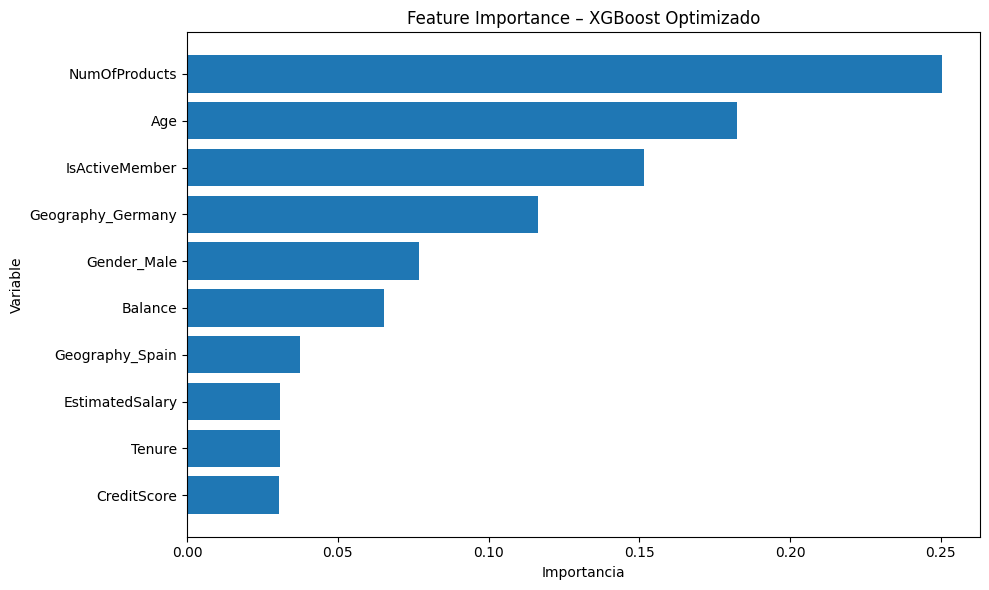

In [39]:
# Obtener el modelo XGBoost optimizado
xgb_best_pipeline = grid_search_xgb.best_estimator_
xgb_best_model = xgb_best_pipeline.named_steps["model"]

# Obtener nombres de las features
preprocessor = xgb_best_pipeline.named_steps["preprocessor"]

num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][1].get_feature_names_out(
    preprocessor.transformers_[1][2]
)

feature_names = list(num_features) + list(cat_features)

# Crear DataFrame de importancia
importances = xgb_best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Gráfico
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance_df["Feature"][:10][::-1],
    feature_importance_df["Importance"][:10][::-1]
)
plt.title("Feature Importance – XGBoost Optimizado")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


El gráfico de importancia de variables muestra cuáles son los factores que más influyen en la predicción de churn según el modelo XGBoost optimizado.

Se observa que **NumOfProducts**, **Age** e **IsActiveMember** son las variables más relevantes, lo que indica que el nivel de vinculación del cliente con el banco y su comportamiento activo tienen un impacto clave en la probabilidad de abandono. 

Asimismo, variables como **Geography** y **Balance** aportan información adicional, mientras que **CreditScore** y **Tenure** presentan un peso menor en la decisión del modelo. Estos resultados permiten orientar estrategias de retención focalizadas en los perfiles con mayor riesgo de churn.


In [40]:

# 13.1 Estimators usando XGBoost (GridSearch)
# ==================================

xgb_best_model = xgb_final_pipeline.named_steps["model"]
lgbm_base_model = lgbm_pipeline.named_steps["model"]
cat_base_model = cat_pipeline.named_steps["model"]

estimators = [
    ("xgb", xgb_best_model),
    ("lgbm", lgbm_base_model),
    ("cat", cat_base_model)
]


In [41]:

# 13.2 StackingClassifier
# ==================================

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    stack_method="predict_proba",
    cv=cv,
    n_jobs=-1
)


In [42]:

# 13.3 Pipeline del Stacking
# ==================================

stacking_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", stacking_model)
    ]
)


Se utiliza Regresión Logística como meta-learner porque es un modelo simple y regularizado que aprende a combinar las probabilidades generadas por modelos base complejos (boosting) sin sobreajustarse.
Al trabajar sobre probabilidades (stack_method='predict_proba'), el meta-modelo puede “suavizar” y ponderar las salidas de cada modelo base, reduciendo el riesgo de overfitting en el nivel 2 y mejorando la generalización.

In [43]:

# 13.4 Evaluación Stacking (CV)
# ==================================

stacking_cv_results = cross_validate(
    stacking_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Stacking – métricas promedio (CV):")
for metric in scoring.keys():
    print(f"{metric}: {stacking_cv_results['test_' + metric].mean():.4f}")


Stacking – métricas promedio (CV):
accuracy: 0.7940
precision: 0.4967
recall: 0.7552
roc_auc: 0.8656
pr_auc: 0.7028


In [44]:

# 13.5 Comparación mejor modelo vs Stacking
# ==================================

comparison_final = pd.DataFrame({
    "Modelo": ["CatBoost (mejor base)", "XGBoost Optimizado", "Stacking"],
    "PR-AUC": [
        cat_cv_results["test_pr_auc"].mean(),
        xgb_best_cv_results["test_pr_auc"].mean(),
        stacking_cv_results["test_pr_auc"].mean()
    ],
    "Recall": [
        cat_cv_results["test_recall"].mean(),
        xgb_best_cv_results["test_recall"].mean(),
        stacking_cv_results["test_recall"].mean()
    ],
    "ROC-AUC": [
        cat_cv_results["test_roc_auc"].mean(),
        xgb_best_cv_results["test_roc_auc"].mean(),
        stacking_cv_results["test_roc_auc"].mean()
    ]
})

comparison_final


,Modelo,PR-AUC,Recall,ROC-AUC
0,CatBoost (mejor base),0.691299,0.686503,0.855988
1,XGBoost Optimizado,0.702217,0.738037,0.865700
2,Stacking,0.702765,0.755215,0.865616


En este paso se implementó un modelo de Stacking como técnica de ensemble, combinando XGBoost optimizado, LightGBM y CatBoost como modelos base, y una Regresión Logística regularizada como meta-learner. El modelo fue evaluado mediante validación cruzada estratificada utilizando métricas adecuadas para datos desbalanceados.

Los resultados obtenidos muestran que el enfoque de Stacking permite mejorar la capacidad del modelo para identificar clientes con churn, alcanzando el mayor valor de Recall y un PR-AUC levemente superior al de los modelos individuales. Si bien se observa una disminución en accuracy y precision, este comportamiento es esperado y aceptable en problemas de churn, donde la prioridad es minimizar los falsos negativos.

En consecuencia, el modelo de Stacking se presenta como una estrategia avanzada y efectiva para la predicción de churn, especialmente útil en escenarios donde se prioriza la detección temprana de clientes en riesgo.

 Métrica de negocio personalizada (impacto monetario)

Para traducir el desempeño del modelo a negocio, estimo el número de clientes churners detectados y potencialmente retenidos.
Dado que el churn es desbalanceado y el objetivo es no perder clientes en riesgo, utilizo Recall como métrica principal.
Como no todos los clientes contactados se retienen, incorporo una tasa de éxito de retención y calculo el impacto monetario bajo escenarios (conservador/medio/agresivo) en un horizonte de meses.

In [45]:

# 11.B Métrica de negocio (escenarios)
# ==================================

clientes_totales = 10000
churn_rate_actual = 0.20

# Elegí el recall del modelo que quieras "defender" como estrategia final.
# Recomendación: usar el stacking (mejor recall y PR-AUC).
recall_modelo = stacking_cv_results["test_recall"].mean()

churners_actuales = clientes_totales * churn_rate_actual
churners_detectados = churners_actuales * recall_modelo

escenarios = [
    {"Escenario": "Conservador", "ARPU_mensual": 15000, "Margen": 0.25, "Meses": 3,  "Exito_retencion": 0.30},
    {"Escenario": "Medio",       "ARPU_mensual": 20000, "Margen": 0.30, "Meses": 6,  "Exito_retencion": 0.40},
    {"Escenario": "Agresivo",    "ARPU_mensual": 25000, "Margen": 0.35, "Meses": 12, "Exito_retencion": 0.50},
]

rows = []
for e in escenarios:
    churners_retenidos = churners_detectados * e["Exito_retencion"]
    valor_por_cliente = e["ARPU_mensual"] * e["Margen"] * e["Meses"]
    impacto = churners_retenidos * valor_por_cliente
    
    rows.append({
        "Escenario": e["Escenario"],
        "Churners actuales estimados": churners_actuales,
        "Recall modelo": recall_modelo,
        "Churners detectados": churners_detectados,
        "Tasa éxito retención": e["Exito_retencion"],
        "Churners retenidos (estim.)": churners_retenidos,
        "Valor por cliente ($)": valor_por_cliente,
        "Impacto monetario ($)": impacto
    })

df_impacto = pd.DataFrame(rows)

# Mostrar tabla con números más legibles
df_impacto[[
    "Escenario",
    "Churners actuales estimados",
    "Recall modelo",
    "Churners detectados",
    "Tasa éxito retención",
    "Churners retenidos (estim.)",
    "Valor por cliente ($)",
    "Impacto monetario ($)"
]]


,Escenario,Churners actuales estimados,Recall modelo,Churners detectados,Tasa éxito retención,Churners retenidos (estim.),Valor por cliente ($),Impacto monetario ($)
0,Conservador,2000.0,0.755215,1510.429448,0.3,453.128834,11250.0,5.097699e+06
1,Medio,2000.0,0.755215,1510.429448,0.4,604.171779,36000.0,2.175018e+07
2,Agresivo,2000.0,0.755215,1510.429448,0.5,755.214724,105000.0,7.929755e+07


Interpretación: en función del Recall del modelo, se estima cuántos clientes que iban a abandonar se logran identificar. Luego, aplicando una tasa de éxito de retención, se obtiene una estimación de clientes efectivamente retenidos. Bajo distintos escenarios de ARPU, margen y horizonte temporal, se calcula el impacto monetario potencial de reducir churn mediante acciones proactivas.

Conclusion: 

En este avance se profundizó el desarrollo del modelo de predicción de churn incorporando modelos avanzados de Machine Learning, técnicas de optimización de hiperparámetros y métodos de ensemble.

La comparación de modelos mostró que los algoritmos de Gradient Boosting superan a Random Forest en métricas clave para problemas desbalanceados. En particular, CatBoost se destacó como el mejor modelo base, logrando el mayor PR-AUC y Recall, lo que indica una mejor capacidad para detectar clientes con riesgo de abandono.

La optimización de hiperparámetros aplicada a XGBoost permitió mejorar aún más su desempeño, especialmente en Recall y PR-AUC, reforzando su utilidad para estrategias de retención. Finalmente, el modelo de Stacking combinó la información de distintos modelos y obtuvo el mejor equilibrio global, maximizando la detección de churn a costa de una leve reducción en accuracy.

En conjunto, los resultados confirman que priorizar métricas orientadas a la clase minoritaria permite construir modelos más alineados con los objetivos de negocio del banco, sentando una base sólida para la etapa final del proyecto.